# Inference Recorder Review
This notebook is focused on visually checking what the inference recorder is saving.
It is intentionally exploratory and tolerant to partial runs.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.notebooks.review_utils import (
    PROJECT_ROOT,
    discover_recorder_payloads,
    list_recorder_files,
    load_recorder_payload,
    payload_summary_frame,
    activation_inventory_frame,
    plot_scanpath_overview,
    plot_attention_heatmap,
    plot_sampling_locations,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 120)
PROJECT_ROOT

WindowsPath('C:/Users/ulloa/Miooooo/Master/thesis/projectes/From-Noisy-Eye-Tracking-To-Scanpath')

In [2]:
all_pt_files = list_recorder_files()
display(all_pt_files.head(20))

recorder_files = discover_recorder_payloads(limit=50)
display(recorder_files)

if recorder_files.empty:
    print('No inference-recorder payloads were found yet. Once a run produces *.pt payloads, re-run this notebook.')

,file,modified,size_kb
0,outputs\outputs\2026-03-16\18-24-45\inference_records\train_epoch_0020_batch_00164_step_003299_Fixation.pt,2026-03-17 10:21:18.139412403,10222.6
1,outputs\outputs\2026-03-16\18-24-45\inference_records\val_epoch_0135_batch_00054_Combined.pt,2026-03-17 10:21:18.042153597,7670.1
2,outputs\outputs\2026-03-16\18-24-45\inference_records\train_epoch_0055_batch_00164_step_009074_Combined.pt,2026-03-17 10:21:17.966344118,10951.3
3,outputs\outputs\2026-03-16\18-24-45\inference_records\train_epoch_0135_batch_00164_step_022274_Combined.pt,2026-03-17 10:21:17.860257626,10469.6
4,outputs\outputs\2026-03-16\18-24-45\inference_records\val_epoch_0100_batch_00054_Combined.pt,2026-03-17 10:21:17.760137081,7670.1
5,outputs\outputs\2026-03-16\18-24-45\inference_records\train_epoch_0120_batch_00164_step_019799_Combined.pt,2026-03-17 10:21:17.683246136,10710.4
6,outputs\outputs\2026-03-16\18-24-45\inference_records\val_epoch_0020_batch_00054_Fixation.pt,2026-03-17 10:21:17.583017349,7668.3
7,outputs\outputs\2026-03-16\18-24-45\inference_records\val_epoch_0130_batch_00054_Combined.pt,2026-03-17 10:21:17.503085852,7670.1
8,outputs\outputs\2026-03-16\18-24-45\inference_records\val_epoch_0065_batch_00054_Combined.pt,2026-03-17 10:21:17.423606157,6860.6
9,outputs\outputs\2026-03-16\18-24-45\inference_records\train_epoch_0100_batch_00164_step_016499_Combined.pt,2026-03-17 10:21:17.355309725,10951.3


,file,split,phase,epoch,batch_index,global_step,modified,size_kb
0,outputs\outputs\2026-03-16\18-24-45\inference_records\train_epoch_0020_batch_00164_step_003299_Fixation.pt,train,Fixation,20,164,3299.0,2026-03-17 10:21:18.139412403,10222.6
1,outputs\outputs\2026-03-16\18-24-45\inference_records\val_epoch_0135_batch_00054_Combined.pt,val,Combined,135,54,NaN,2026-03-17 10:21:18.042153597,7670.1
2,outputs\outputs\2026-03-16\18-24-45\inference_records\train_epoch_0055_batch_00164_step_009074_Combined.pt,train,Combined,55,164,9074.0,2026-03-17 10:21:17.966344118,10951.3
3,outputs\outputs\2026-03-16\18-24-45\inference_records\train_epoch_0135_batch_00164_step_022274_Combined.pt,train,Combined,135,164,22274.0,2026-03-17 10:21:17.860257626,10469.6
4,outputs\outputs\2026-03-16\18-24-45\inference_records\val_epoch_0100_batch_00054_Combined.pt,val,Combined,100,54,NaN,2026-03-17 10:21:17.760137081,7670.1
5,outputs\outputs\2026-03-16\18-24-45\inference_records\train_epoch_0120_batch_00164_step_019799_Combined.pt,train,Combined,120,164,19799.0,2026-03-17 10:21:17.683246136,10710.4
6,outputs\outputs\2026-03-16\18-24-45\inference_records\val_epoch_0020_batch_00054_Fixation.pt,val,Fixation,20,54,NaN,2026-03-17 10:21:17.583017349,7668.3
7,outputs\outputs\2026-03-16\18-24-45\inference_records\val_epoch_0130_batch_00054_Combined.pt,val,Combined,130,54,NaN,2026-03-17 10:21:17.503085852,7670.1
8,outputs\outputs\2026-03-16\18-24-45\inference_records\val_epoch_0065_batch_00054_Combined.pt,val,Combined,65,54,NaN,2026-03-17 10:21:17.423606157,6860.6
9,outputs\outputs\2026-03-16\18-24-45\inference_records\train_epoch_0100_batch_00164_step_016499_Combined.pt,train,Combined,100,164,16499.0,2026-03-17 10:21:17.355309725,10951.3


In [3]:
selected_path = None
if not recorder_files.empty:
    selected_path = PROJECT_ROOT / recorder_files.iloc[0]['file']
selected_path

WindowsPath('C:/Users/ulloa/Miooooo/Master/thesis/projectes/From-Noisy-Eye-Tracking-To-Scanpath/outputs/outputs/2026-03-16/18-24-45/inference_records/train_epoch_0020_batch_00164_step_003299_Fixation.pt')

In [4]:
if selected_path is not None:
    payload = load_recorder_payload(selected_path)
    display(payload.get('metadata', {}))
    display(payload_summary_frame(payload))

{'epoch': 20,
 'phase': 'Fixation',
 'split': 'train',
 'batch_index': 164,
 'global_step': 3299,
 'model_name': 'MixerModel',
 'phase_epoch': 20}

,section,name,shape,dtype
0,data,sample_idx,"(58,)",torch.int64
1,data,image_idx,"(58,)",torch.int64
2,data,eye_tracking_input,"(58, 13, 3)",torch.float32
3,data,fixation_ground_truth,"(58, 10, 3)",torch.float32
4,outputs,scanpath_coordinates,"(58, 11, 2)",torch.float32
5,outputs,scanpath_duration,"(58, 11, 1)",torch.float32
6,outputs,scanpath_end_logits,"(58, 11, 1)",torch.float32
7,activations,eye_decoder.0.cross_attn.sampling_offsets,"(58, 13, 8, 4, 2)",list
8,activations,eye_decoder.0.cross_attn.attention_weights,"(58, 13, 8, 4)",list
9,activations,eye_decoder.0.cross_attn.sampling_locations,"(58, 13, 8, 4, 2)",list


In [5]:
if selected_path is not None:
    display(activation_inventory_frame(payload).sort_values(['module', 'activation']).reset_index(drop=True))

,module,activation,shape,captures
0,decoder.0.first_cross_attn,attention_weights,"(58, 8, 11, 13)",1
1,decoder.0.second_cross_attn,attention_weights,"(58, 11, 8, 4)",1
2,decoder.0.second_cross_attn,sampling_locations,"(58, 11, 8, 4, 2)",1
3,decoder.0.second_cross_attn,sampling_offsets,"(58, 11, 8, 4, 2)",1
4,decoder.1.first_cross_attn,attention_weights,"(58, 8, 11, 13)",1
5,decoder.1.second_cross_attn,attention_weights,"(58, 11, 8, 4)",1
6,decoder.1.second_cross_attn,sampling_locations,"(58, 11, 8, 4, 2)",1
7,decoder.1.second_cross_attn,sampling_offsets,"(58, 11, 8, 4, 2)",1
8,decoder.2.first_cross_attn,attention_weights,"(58, 8, 11, 13)",1
9,decoder.2.second_cross_attn,attention_weights,"(58, 11, 8, 4)",1


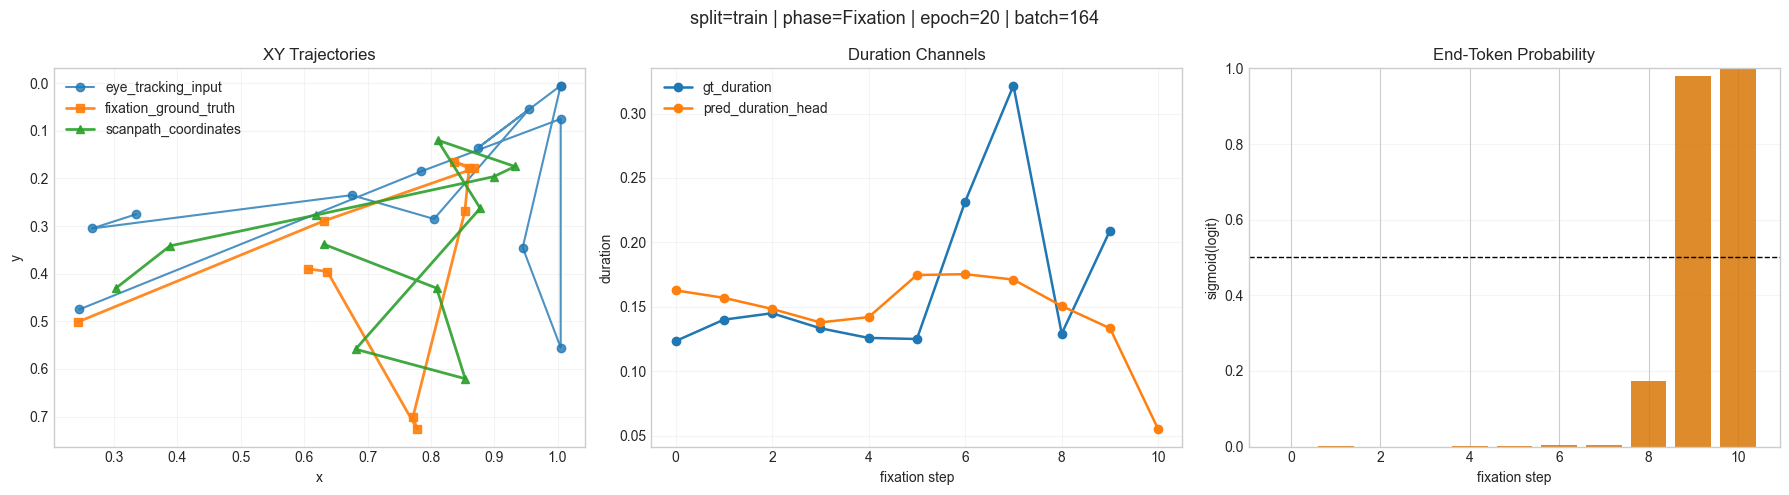

In [6]:
if selected_path is not None:
    plot_scanpath_overview(payload, sample_index=0)

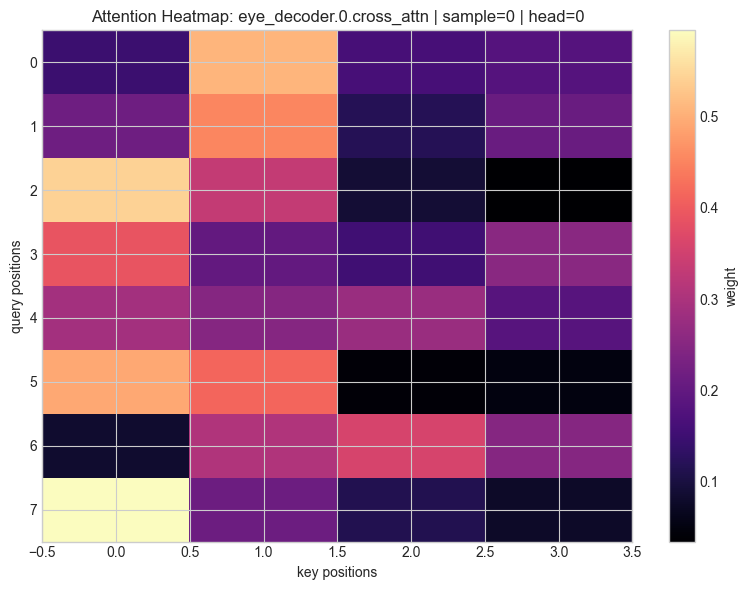

In [7]:
if selected_path is not None:
    try:
        plot_attention_heatmap(payload, sample_index=0, head_index=0)
    except ValueError as exc:
        print(exc)

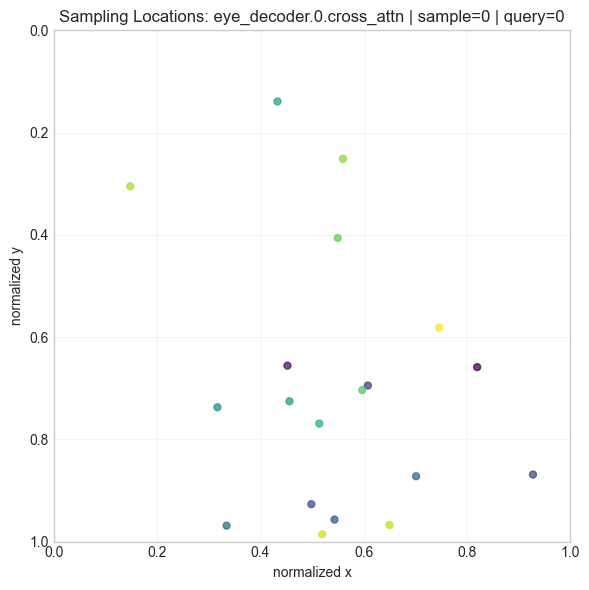

In [8]:
if selected_path is not None:
    try:
        plot_sampling_locations(payload, sample_index=0, query_index=0)
    except ValueError as exc:
        print(exc)

## Notes
- `data` comes from `InferenceRecorder.record_batch` and currently includes indices plus input/target tensors when present.
- `outputs` includes `denoise`, `coord`, `dur`, `reg`, and `cls` under more descriptive names.
- `activations` currently come from attention modules in `blocks.py`, mainly cross-attention weights and deformable-attention sampling tensors.